# Exploração Histórica da Otimização Federada

Este notebook analisa o histórico de simulação salvo pelo `FLPOPT`. Os dados já estão formatados em DataFrames separados (`df_inputs` e `df_chosen`) para tornar a exploração mais intuitiva e isolada.

In [41]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('historico_20_rodadas.json', 'r') as f:
    history = json.load(f)

print(f"Número de rodadas na simulação: {len(history['chosen_solutions'])}")

Número de rodadas na simulação: 20


In [42]:
import os
os.makedirs('./Figuras', exist_ok=True)
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14, 'font.family': 'serif', 'axes.labelsize': 16, 'xtick.labelsize': 12, 'ytick.labelsize': 12})


## 1. Carregamento dos DataFrames Principais
Extraindo os `inputs` globais e a solução escolhida (`chosen_solutions`) de cada rodada.

In [43]:
df_inputs = pd.DataFrame(history['inputs'])

chosen_records = []
for r, sol in enumerate(history['chosen_solutions']):
    record = {'Rodada': r, 'idx_fronteira': sol.get('idx', np.nan)}
    
    # Objetivos
    if sol['F'] is not None:
        record['f1_energia'] = sol['F'][0]
        record['f2_unselected'] = sol['F'][1]
        record['f3_tempo'] = sol['F'][2]
        
    # Variáveis de decisão X
    for k, v in sol['X'].items():
        record[k] = v
        
    chosen_records.append(record)

df_chosen = pd.DataFrame(chosen_records)

N_devices = len(df_inputs['c'][0])
c_vals = np.array(df_inputs['c'][0])
S_vals = np.array(df_inputs['S'][0])

df_chosen.head()

,Rodada,idx_fronteira,f1_energia,f2_unselected,f3_tempo,T,f_0,theta_0,f_1,theta_1,...,psi_1,psi_2,psi_3,psi_4,psi_5,psi_6,psi_7,psi_8,psi_9,psi_10
0,0,24,6.390961e+22,-8.000000,486.571270,30.637663,1.789601e+09,0.635141,1.513580e+09,0.743589,...,2,2,1,1,2,2,2,2,3,1
1,1,107,5.161593e+22,-8.231368,530.028647,38.176072,1.759154e+09,0.736701,1.659404e+09,0.866427,...,3,4,2,2,2,2,1,2,4,2
2,2,16,6.879741e+22,-8.345835,697.581999,50.715967,1.810271e+09,0.824175,1.520589e+09,0.891033,...,4,2,2,2,2,2,2,3,5,2
3,3,88,9.536253e+22,-8.482254,681.033170,50.158648,1.599431e+09,0.837720,1.741766e+09,0.946280,...,5,3,1,3,3,2,4,2,5,5
4,4,22,9.051634e+22,-9.739669,746.022196,54.468050,1.624281e+09,0.870839,1.603961e+09,0.965258,...,5,3,2,3,3,2,3,3,5,4


## 2. Histórico de Punição: `unselected_count`
Analisando quantas rodadas cada dispositivo passou sem ser escolhido para o treinamento.

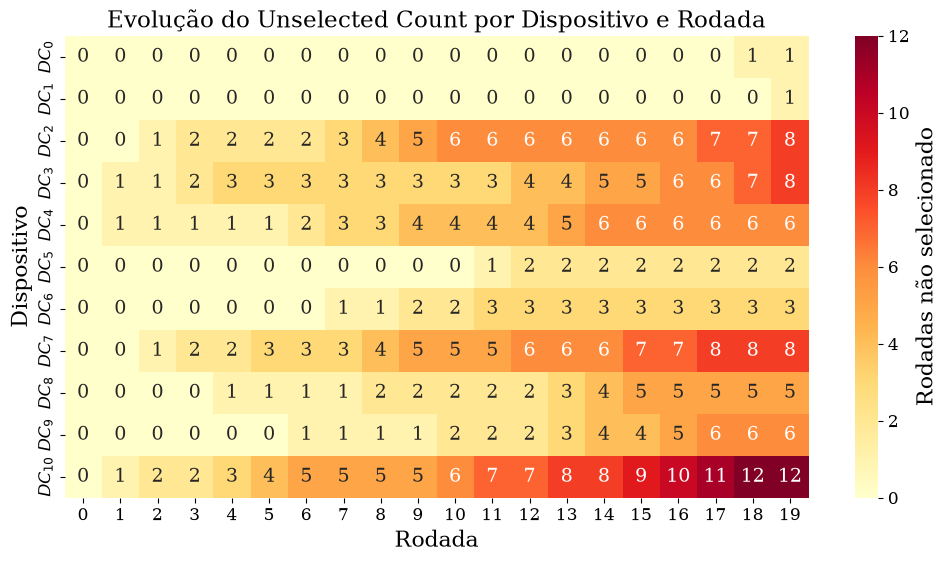

In [44]:
unselected_list = [inp['unselected_count'] for inp in history['inputs']]
df_unselected = pd.DataFrame(unselected_list, columns=[f'$DC_{{{n}}}$' for n in range(N_devices)])

plt.figure(figsize=(12, 6))
sns.heatmap(df_unselected.T, cmap='YlOrRd', annot=True, cbar_kws={'label': 'Rodadas não selecionado'})
plt.title('Evolução do Unselected Count por Dispositivo e Rodada')
plt.xlabel('Rodada')
plt.ylabel('Dispositivo')
plt.savefig('./Figuras/plot_1.eps', format='eps', bbox_inches='tight')
plt.show()

## 3. Evolução das Variáveis de Decisão ($f_n$ e $\psi_n$)
Visualizando o comportamento da frequência e número de épocas apenas para os dispositivos que foram **selecionados** na respectiva rodada.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


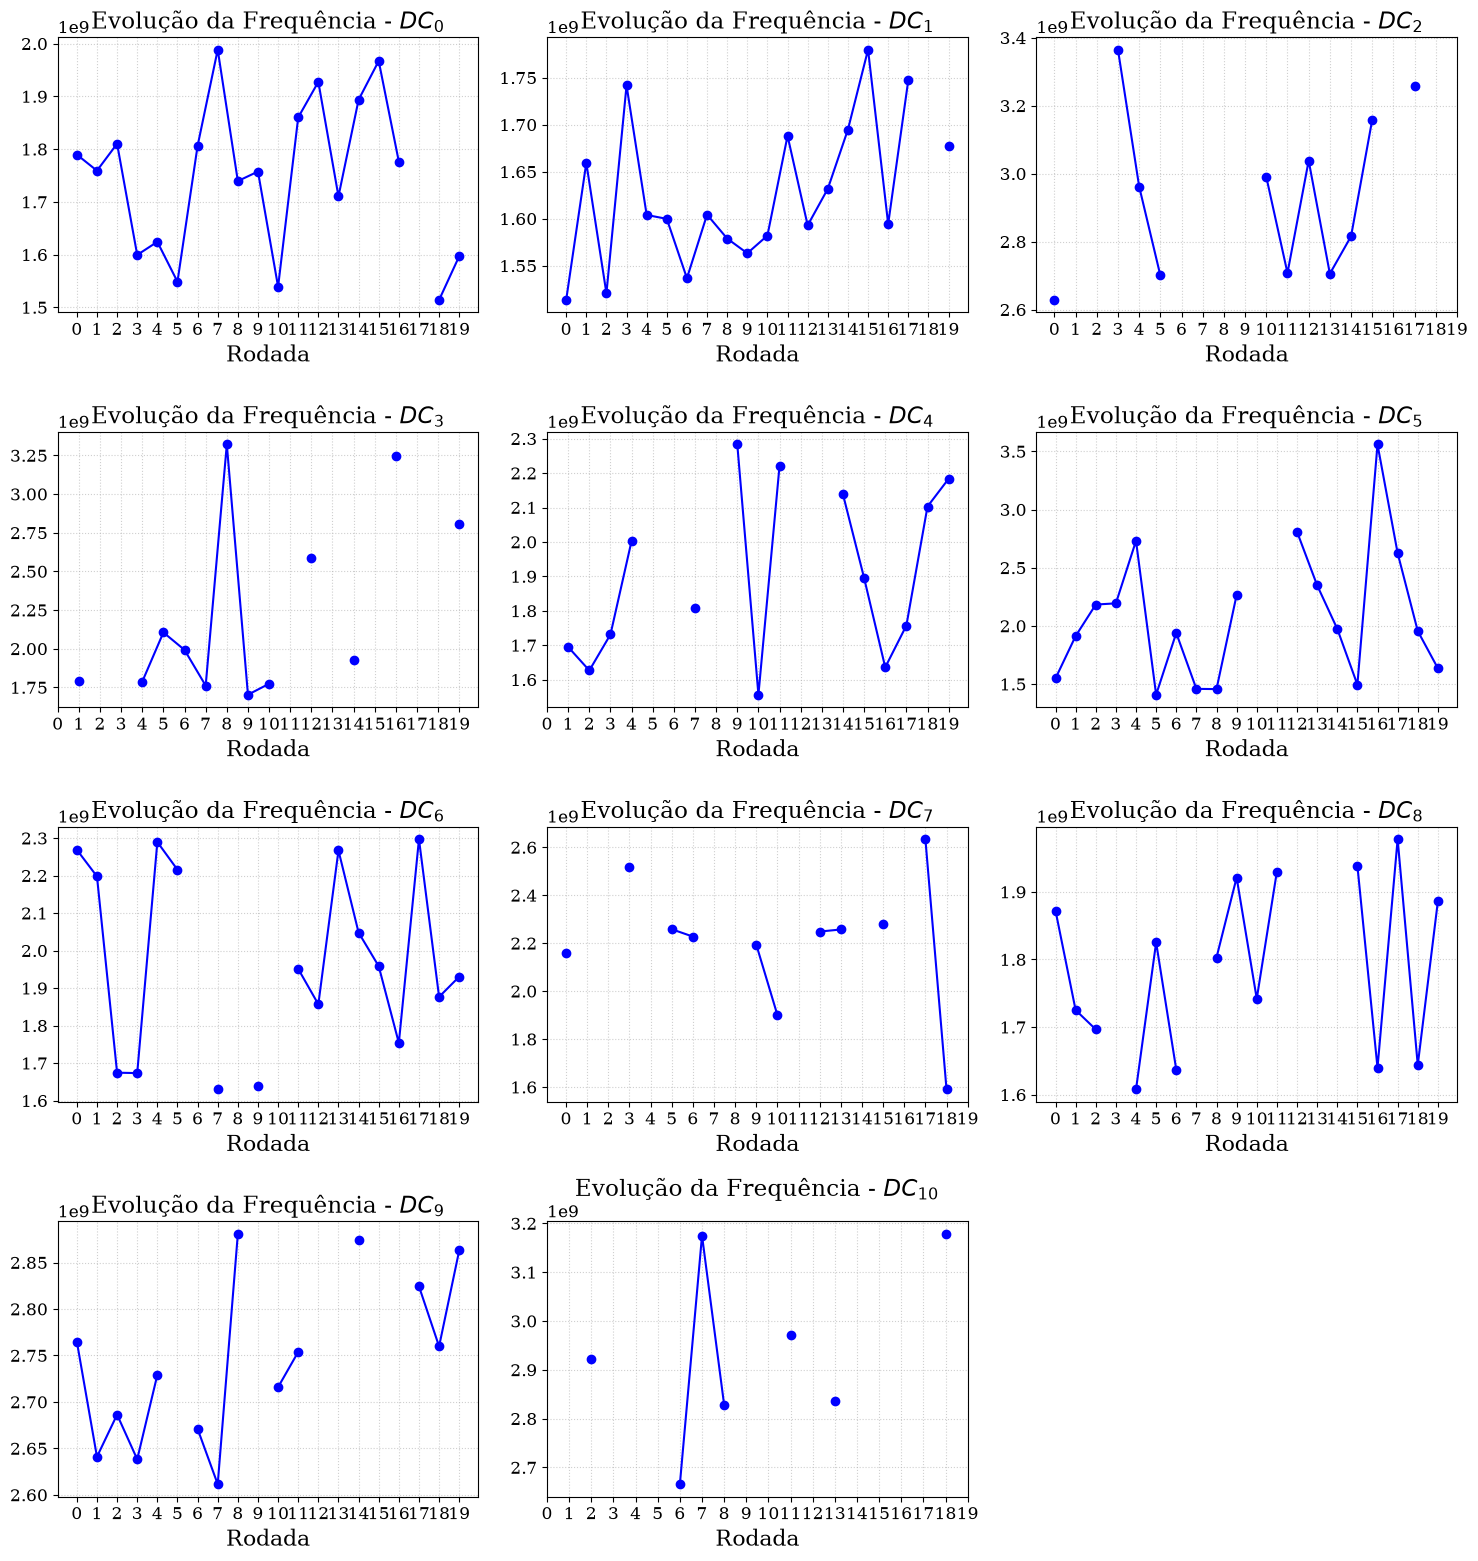

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


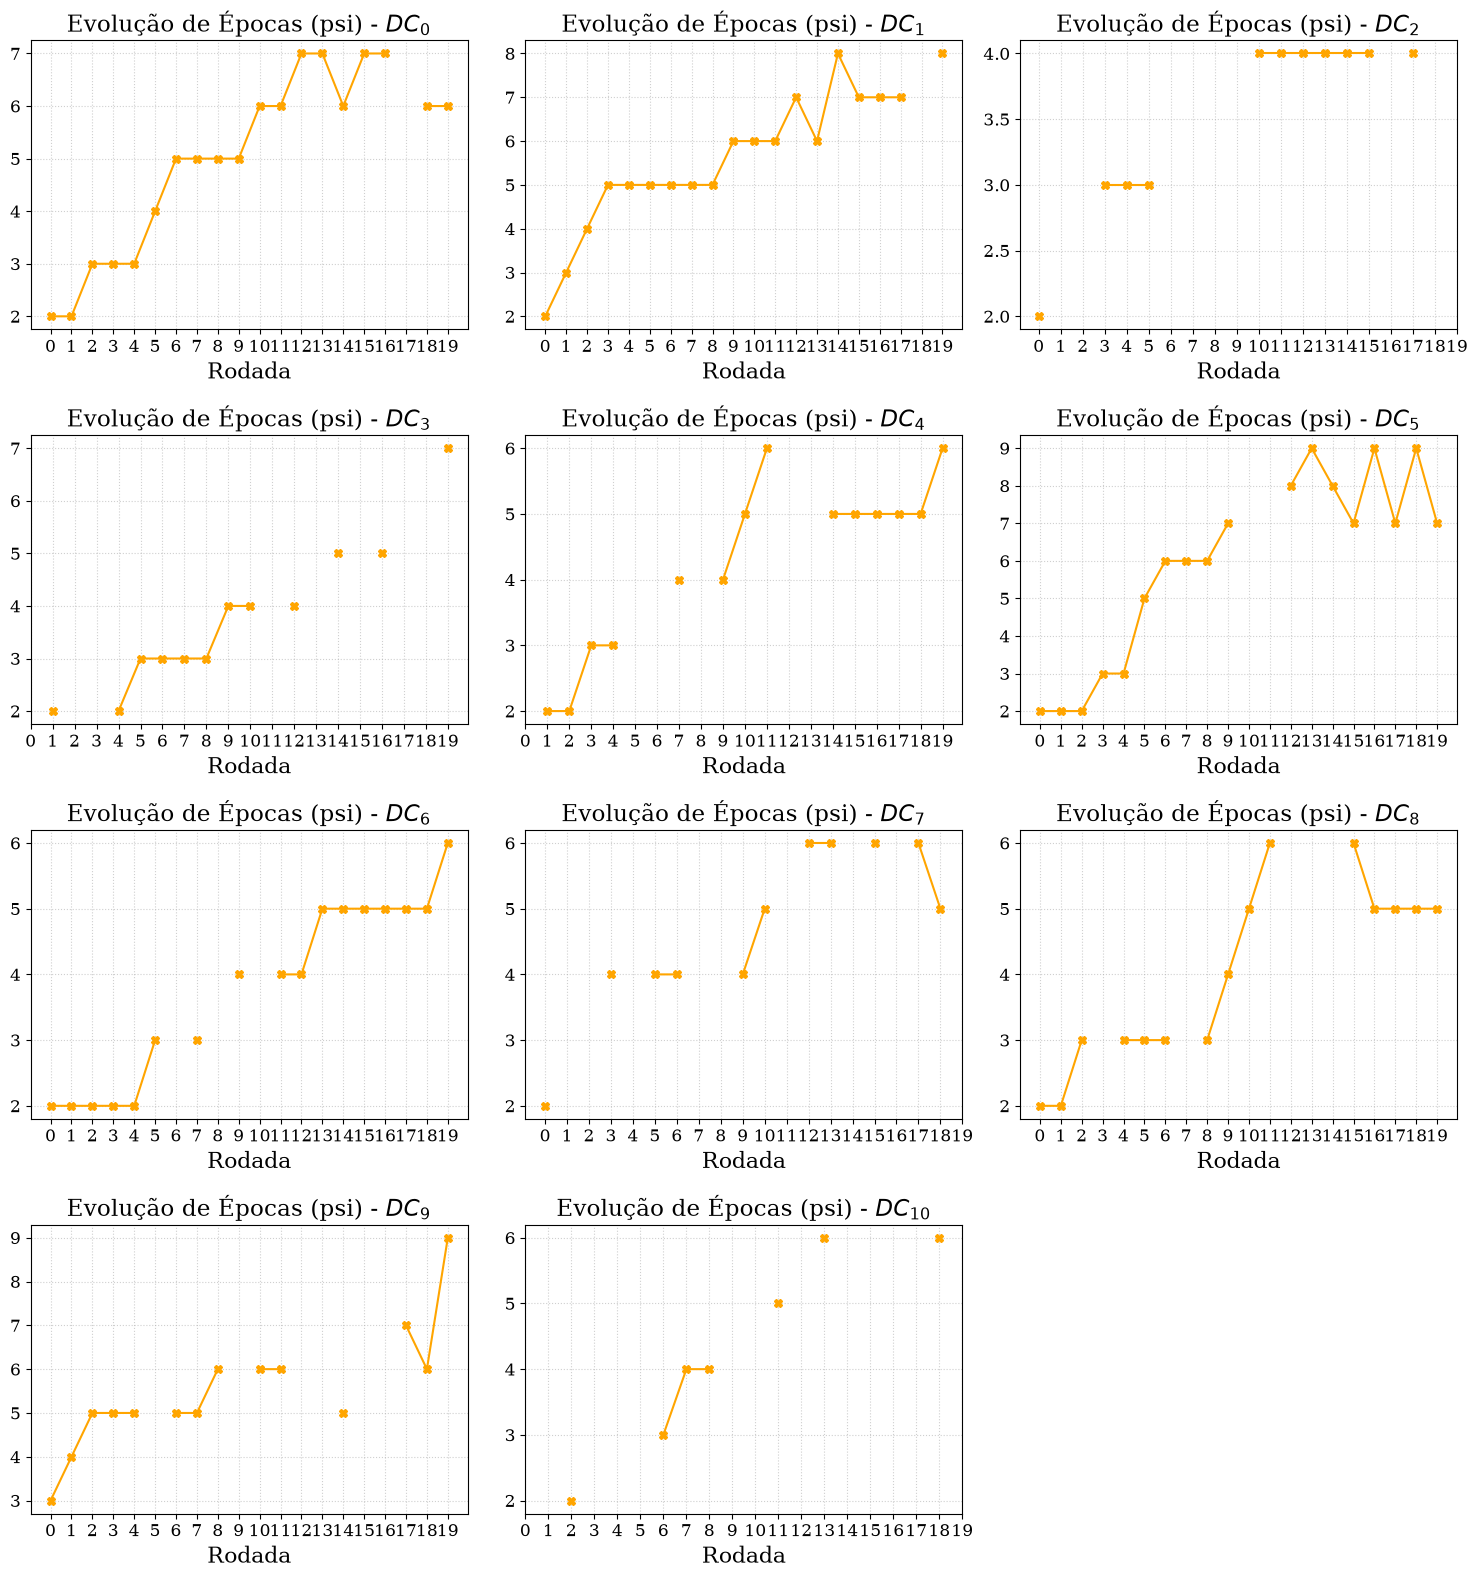

In [45]:
df_f = pd.DataFrame({'Rodada': df_chosen['Rodada']})
df_psi = pd.DataFrame({'Rodada': df_chosen['Rodada']})

for n in range(N_devices):
    mask = df_chosen[f'beta_{n}'] == 1.0
    df_f[f'$DC_{{{n}}}$'] = np.where(mask, df_chosen[f'f_{n}'], np.nan)
    df_psi[f'$DC_{{{n}}}$'] = np.where(mask, df_chosen[f'psi_{n}'], np.nan)

ncols = 3
nrows = math.ceil(N_devices / ncols)

# Frequências
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes_flat = axes.flatten() if N_devices > 1 else [axes]

for n in range(N_devices):
    ax = axes_flat[n]
    ax.plot(df_f['Rodada'], df_f[f'$DC_{{{n}}}$'], marker='o', label='Frequência', color='blue')
    ax.set_title(f'Evolução da Frequência - $DC_{{{n}}}$')
    ax.set_xlabel('Rodada')
    ax.set_xticks(df_f['Rodada'].unique())
    ax.grid(True, linestyle=':', alpha=0.6)

for n in range(N_devices, len(axes_flat)):
    fig.delaxes(axes_flat[n])
plt.tight_layout()
plt.savefig('./Figuras/plot_2.eps', format='eps', bbox_inches='tight')
plt.show()

# Épocas
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes_flat = axes.flatten() if N_devices > 1 else [axes]

for n in range(N_devices):
    ax = axes_flat[n]
    ax.plot(df_psi['Rodada'], df_psi[f'$DC_{{{n}}}$'], marker='X', label='Épocas (psi)', color='orange')
    ax.set_title(f'Evolução de Épocas (psi) - $DC_{{{n}}}$')
    ax.set_xlabel('Rodada')
    ax.set_xticks(df_psi['Rodada'].unique())
    ax.grid(True, linestyle=':', alpha=0.6)

for n in range(N_devices, len(axes_flat)):
    fig.delaxes(axes_flat[n])
plt.tight_layout()
plt.savefig('./Figuras/plot_3.eps', format='eps', bbox_inches='tight')
plt.show()

## 4. Análise de Limites: Tempo da Rodada ($T$) vs Tempo de Treinamento Local
Verifica se o tempo de treinamento dos dispositivos está atingindo a variável restritiva $T$ definida pelo otimizador.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


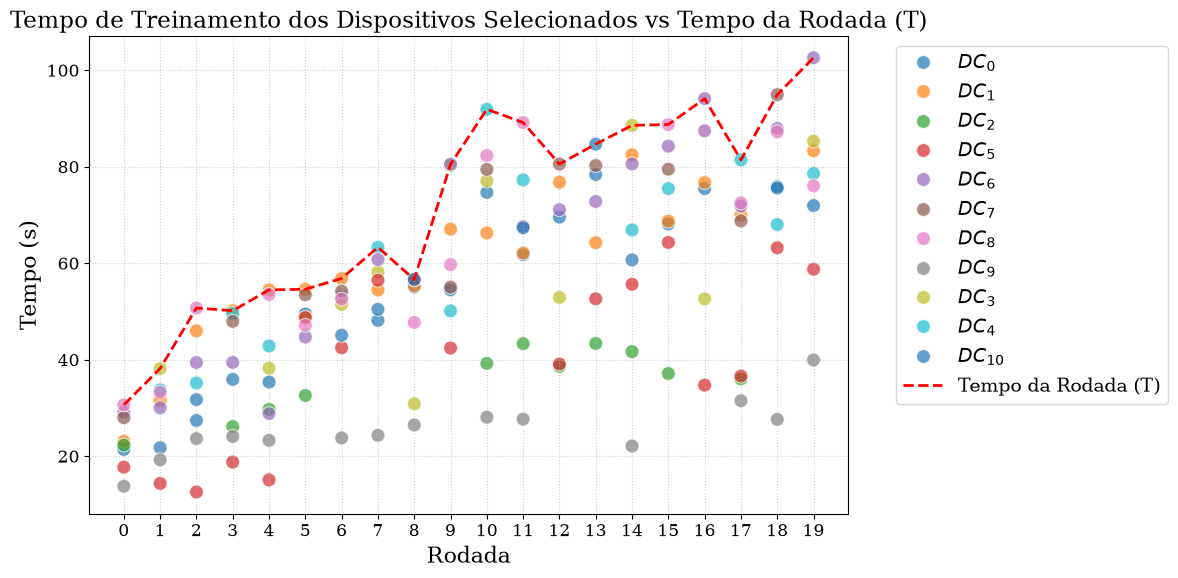

,Rodada,$DC_i$,Tempo
0,0,$DC_{0}$,21.404296
1,0,$DC_{1}$,23.088212
2,0,$DC_{2}$,22.322614
3,0,$DC_{5}$,17.735149
4,0,$DC_{6}$,29.096017
...,...,...,...
152,19,$DC_{4}$,78.611132
153,19,$DC_{5}$,58.778882
154,19,$DC_{6}$,102.585707
155,19,$DC_{8}$,76.030992


In [46]:
times_list = []
psi_comp_list = []
theta_means = []

for r in range(len(df_chosen)):
    row = df_chosen.iloc[r]
    T_val = row['T']
    
    theta_r = []
    for n in range(N_devices):
        if row[f'beta_{n}'] == 1.0:
            f_n = row[f'f_{n}']
            psi_n = row[f'psi_{n}']
            theta_n = row[f'theta_{n}']
            
            # Tempo local do dispositivo
            f_n_hz = f_n
            t_n = (psi_n * c_vals[n] * S_vals[n]) / f_n_hz
            times_list.append({'Rodada': r, '$DC_i$': f'$DC_{{{n}}}$', 'Tempo': t_n})
            
            # Comparação de Psi mínimo
            psi_min = -np.log2(1 - theta_n)
            psi_comp_list.append({'Rodada': r, '$DC_i$': f'$DC_{{{n}}}$', 'psi': psi_n, 'Psi_min': psi_min})
            
            theta_r.append(theta_n)
            
    theta_means.append({'Rodada': r, 'Theta_Medio': np.mean(theta_r) if theta_r else np.nan})

df_times = pd.DataFrame(times_list)
df_psi_comp = pd.DataFrame(psi_comp_list)
df_theta = pd.DataFrame(theta_means)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_times, x='Rodada', y='Tempo', hue='$DC_i$', palette='tab10', s=100, marker='o', alpha=0.7)
plt.plot(df_chosen['Rodada'], df_chosen['T'], color='red', linewidth=2, label='Tempo da Rodada (T)', linestyle='--')
plt.title('Tempo de Treinamento dos Dispositivos Selecionados vs Tempo da Rodada (T)')
plt.ylabel('Tempo (s)')
plt.xlabel('Rodada')
plt.xticks(df_chosen['Rodada'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('./Figuras/plot_4.eps', format='eps', bbox_inches='tight')
plt.show()

df_times

## 5. Análise de Limites: Épocas exigidas ($\Psi_{min}$) e Fator de Acurácia ($\theta$)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


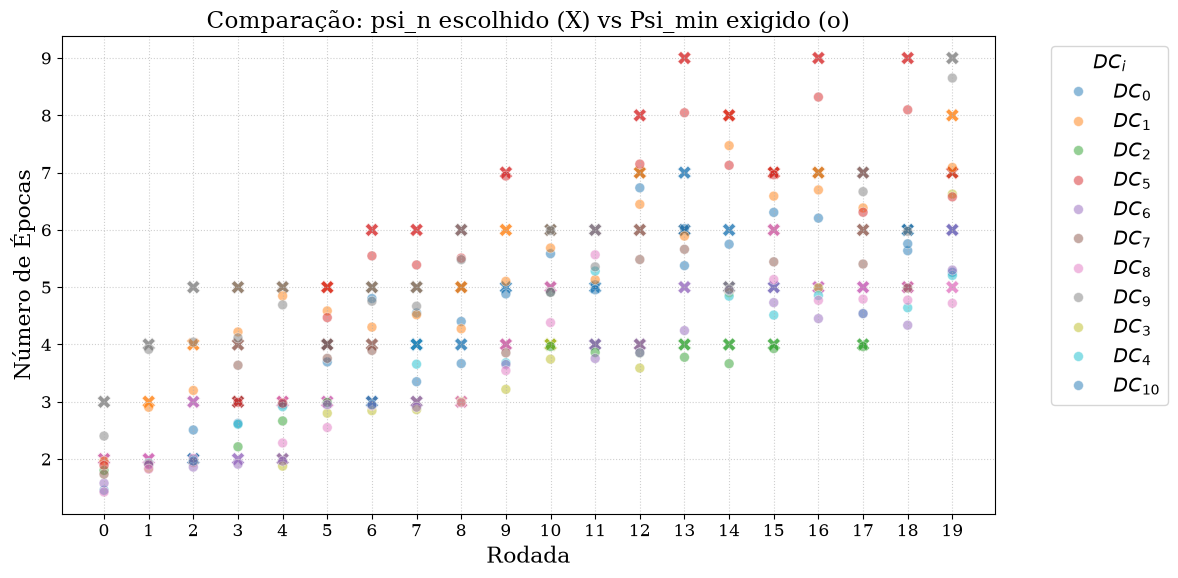

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


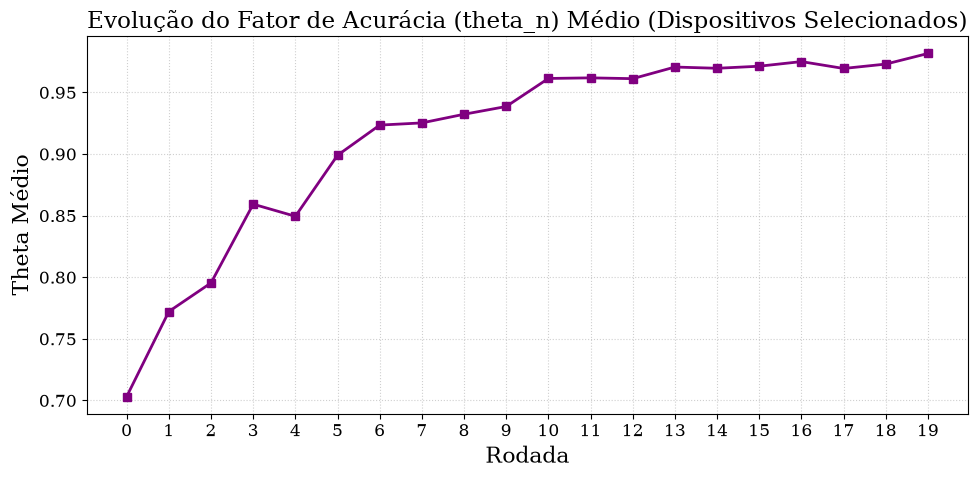

In [47]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_psi_comp, x='Rodada', y='psi', hue='$DC_i$', palette='tab10', s=100, marker='X', alpha=0.8, legend=False)
sns.scatterplot(data=df_psi_comp, x='Rodada', y='Psi_min', hue='$DC_i$', palette='tab10', s=50, marker='o', alpha=0.5)
plt.title('Comparação: psi_n escolhido (X) vs Psi_min exigido (o)')
plt.ylabel('Número de Épocas')
plt.xlabel('Rodada')
plt.xticks(df_chosen['Rodada'].unique())
plt.legend(title='$DC_i$', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('./Figuras/plot_5.eps', format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_theta['Rodada'], df_theta['Theta_Medio'], marker='s', color='purple', linewidth=2)
plt.title('Evolução do Fator de Acurácia (theta_n) Médio (Dispositivos Selecionados)')
plt.ylabel('Theta Médio')
plt.xlabel('Rodada')
plt.xticks(df_theta['Rodada'].unique())
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('./Figuras/plot_6.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


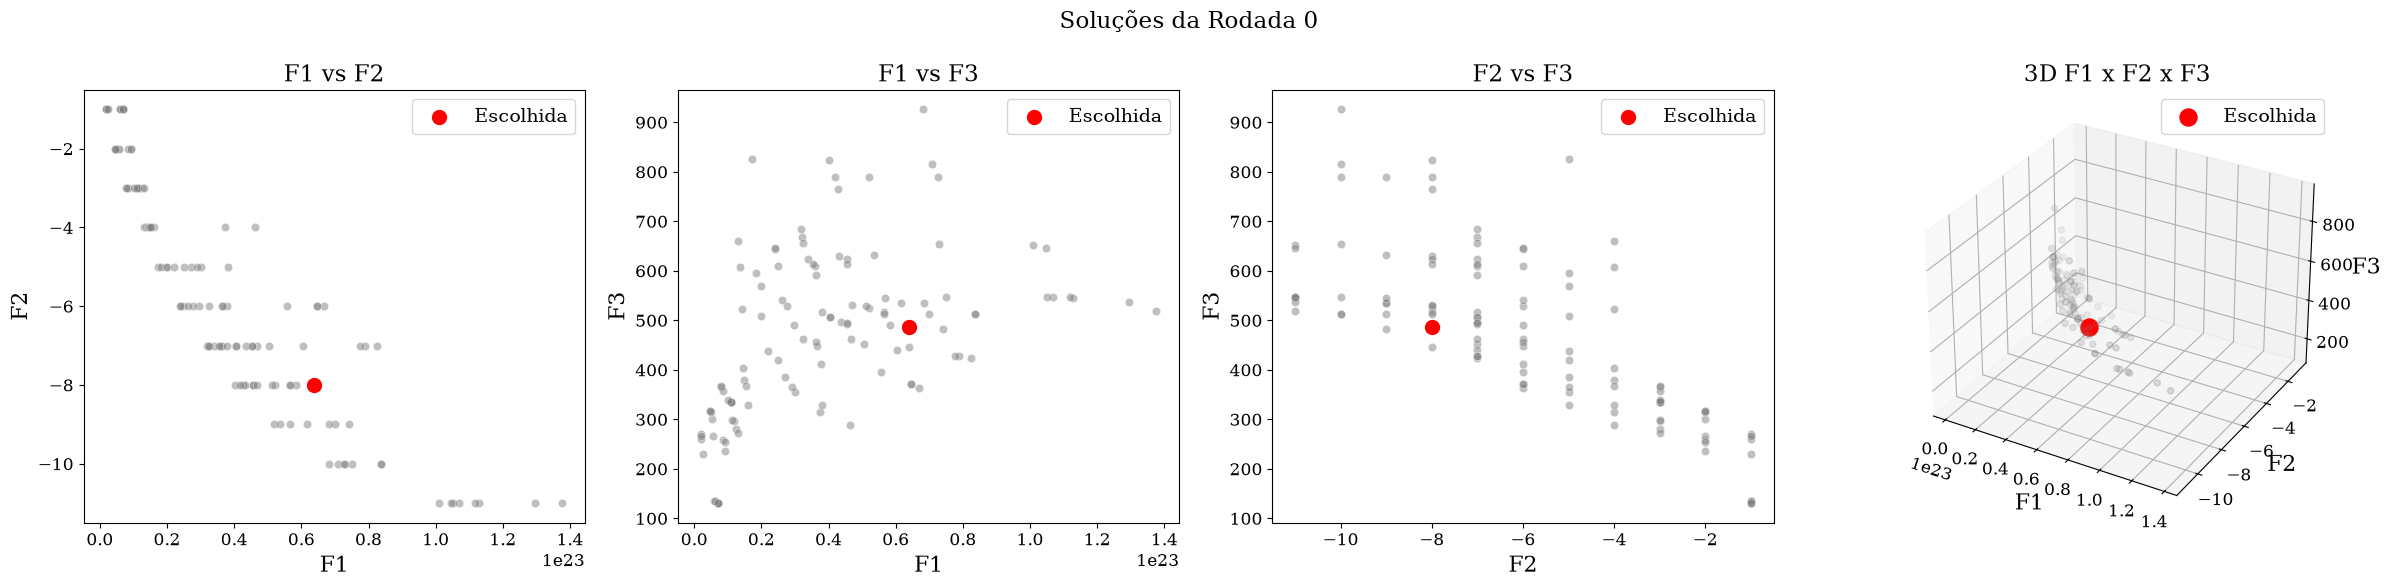

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


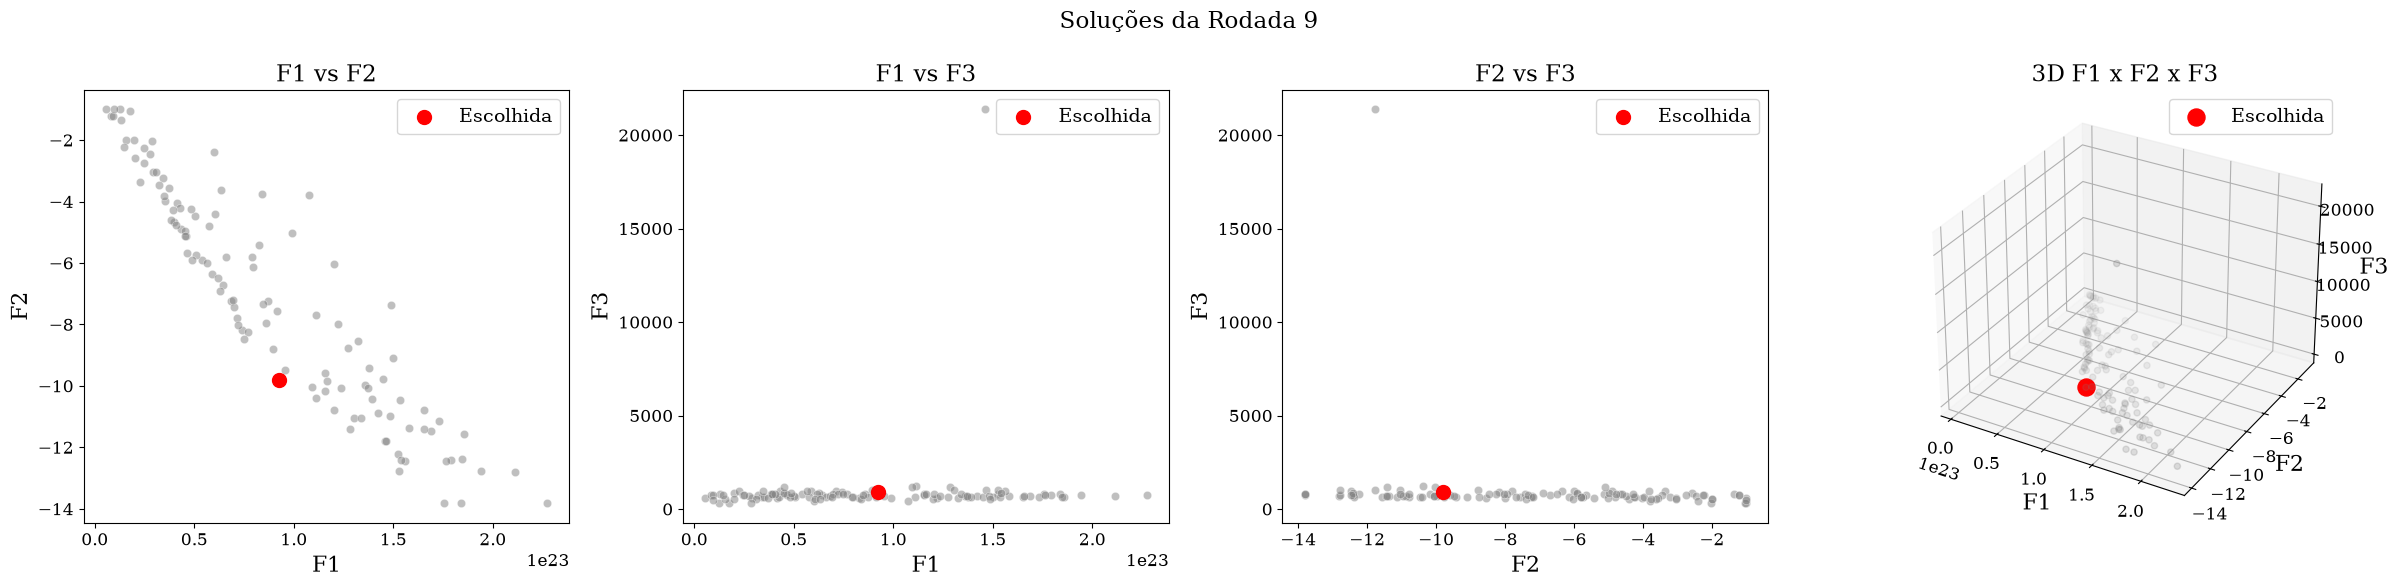

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


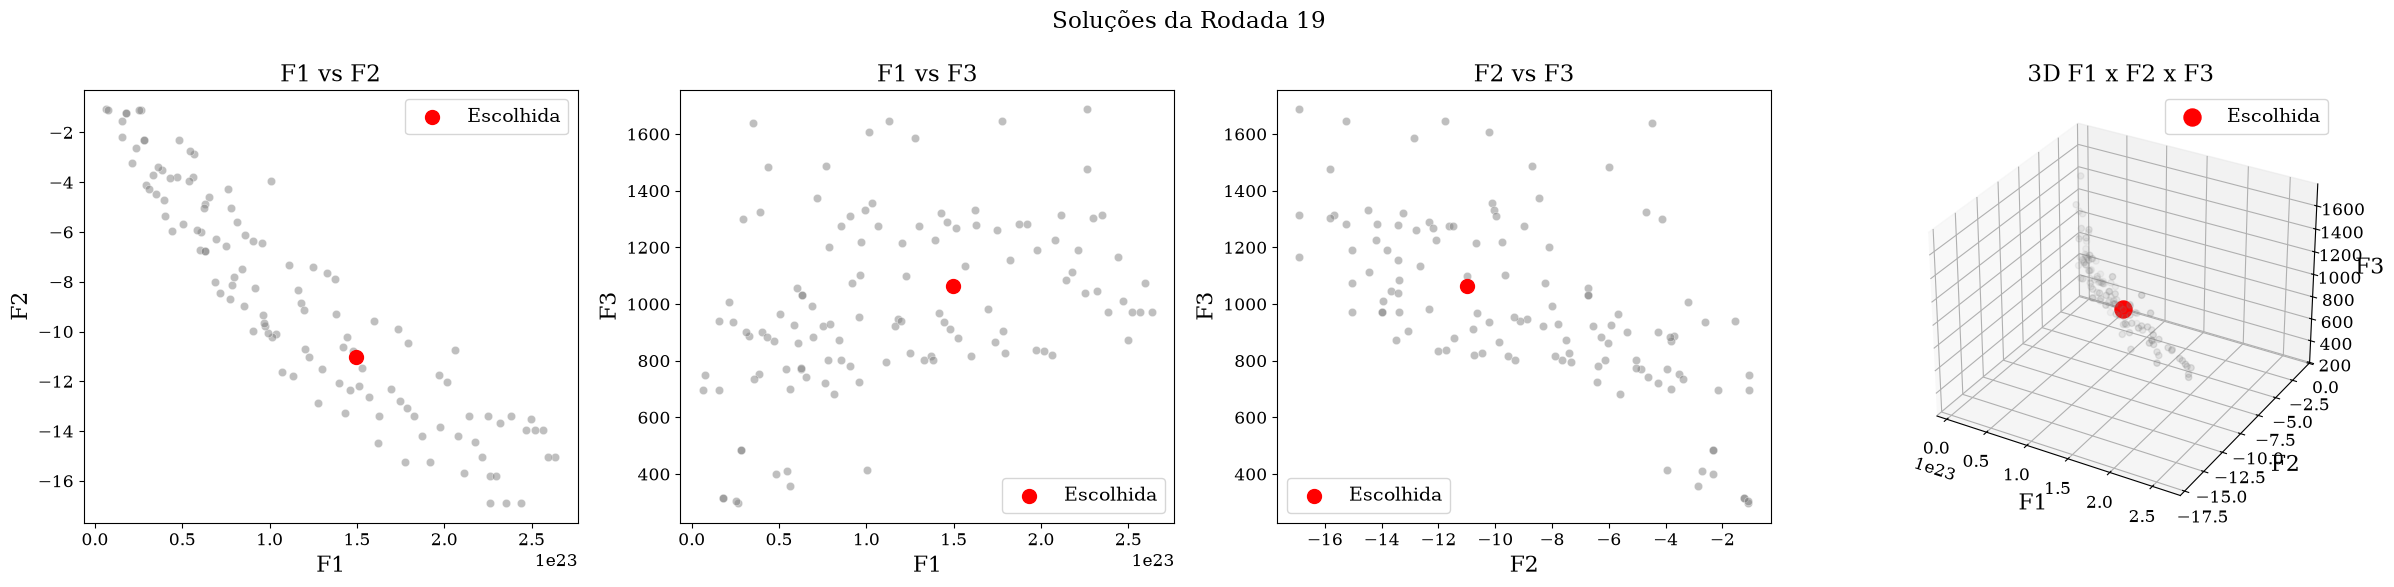

In [48]:
### Novos Plots: Comparação de Soluções (Rodadas Automáticas)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

total_rounds = len(df_chosen)
rounds_to_plot = [0, (total_rounds - 1) // 2, total_rounds - 1]
df_filtered = df_chosen[df_chosen['Rodada'].isin(rounds_to_plot)]

for r in rounds_to_plot:
    if r >= len(history['inputs']): continue
    solutions = history['found_solutions'][r]
    f1, f2, f3 = [], [], []
    for sol in solutions['F']:
        f1.append(sol[0])
        f2.append(sol[1])
        f3.append(sol[2])
    
    df_round = pd.DataFrame({'F1': f1, 'F2': f2, 'F3': f3})
    chosen_sol = df_filtered[df_filtered['Rodada'] == r].iloc[0]
    
    fig = plt.figure(figsize=(24, 6))
    fig.suptitle(f'Soluções da Rodada {r}')
    
    ax1 = fig.add_subplot(141)
    ax2 = fig.add_subplot(142)
    ax3 = fig.add_subplot(143)
    ax4 = fig.add_subplot(144, projection='3d')
    
    # F1 vs F2
    sns.scatterplot(data=df_round, x='F1', y='F2', ax=ax1, color='gray', alpha=0.5)
    ax1.scatter(chosen_sol['f1_energia'], chosen_sol['f2_unselected'], color='red', s=100, label='Escolhida', zorder=5)
    ax1.set_title('F1 vs F2')
    ax1.legend()
    
    # F1 vs F3
    sns.scatterplot(data=df_round, x='F1', y='F3', ax=ax2, color='gray', alpha=0.5)
    ax2.scatter(chosen_sol['f1_energia'], chosen_sol['f3_tempo'], color='red', s=100, label='Escolhida', zorder=5)
    ax2.set_title('F1 vs F3')
    ax2.legend()
    
    # F2 vs F3
    sns.scatterplot(data=df_round, x='F2', y='F3', ax=ax3, color='gray', alpha=0.5)
    ax3.scatter(chosen_sol['f2_unselected'], chosen_sol['f3_tempo'], color='red', s=100, label='Escolhida', zorder=5)
    ax3.set_title('F2 vs F3')
    ax3.legend()
    
    # 3D F1 vs F2 vs F3
    ax4.scatter(df_round['F1'], df_round['F2'], df_round['F3'], color='gray', alpha=0.5)
    ax4.scatter(chosen_sol['f1_energia'], chosen_sol['f2_unselected'], chosen_sol['f3_tempo'], color='red', s=150, label='Escolhida', zorder=5)
    ax4.set_xlabel('F1')
    ax4.set_ylabel('F2')
    ax4.set_zlabel('F3')
    ax4.set_title('3D F1 x F2 x F3')
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig(f'./Figuras/comparacao_rodada_{r}.eps', format='eps', bbox_inches='tight')
    plt.show()


In [49]:
### Tabela LaTeX: Soluções Escolhidas (Rodadas 0, 9 e 19)
import numpy as np
import pandas as pd
records = []
total_rounds = len(df_chosen)
rounds_to_table = [0, (total_rounds - 1) // 2, total_rounds - 1]
df_filtered_table = df_chosen[df_chosen['Rodada'].isin(rounds_to_table)]

for idx, row in df_filtered_table.iterrows():
    r = row['Rodada']
    T = row['T']
    U = -row['f2_unselected']
    for n in range(N_devices):
        psi = row[f'psi_{n}']
        theta = row[f'theta_{n}']
        f_val = row[f'f_{n}'] / 1e9  # Convert to GHz
        records.append({
            'Rodada': int(r), 
            '$DC_i$': f'$DC_{{{n}}}$',
            'T': T, 
            'U': int(U), 
            '$\\psi$': psi, 
            '$\\theta$': theta, 
            '$f$ (GHz)': f_val
        })

df_table = pd.DataFrame(records)
# Using longtable because it will have N_devices * 3 rows
latex_str = df_table.to_latex(index=False, float_format="%.2f", longtable=True, caption="Parâmetros das Soluções Escolhidas por Dispositivo", label="tab:solucoes_dc", escape=False)
with open('tabela_solucoes.tex','w') as tabela:
    tabela.write(latex_str)
print(latex_str)


\begin{longtable}{rlrrrrr}
\caption{Parâmetros das Soluções Escolhidas por Dispositivo} \label{tab:solucoes_dc} \\
\toprule
Rodada & $DC_i$ & T & U & $\psi$ & $\theta$ & $f$ (GHz) \\
\midrule
\endfirsthead
\caption[]{Parâmetros das Soluções Escolhidas por Dispositivo} \\
\toprule
Rodada & $DC_i$ & T & U & $\psi$ & $\theta$ & $f$ (GHz) \\
\midrule
\endhead
\midrule
\multicolumn{7}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
0 & $DC_{0}$ & 30.64 & 8 & 2 & 0.64 & 1.79 \\
0 & $DC_{1}$ & 30.64 & 8 & 2 & 0.74 & 1.51 \\
0 & $DC_{2}$ & 30.64 & 8 & 2 & 0.71 & 2.63 \\
0 & $DC_{3}$ & 30.64 & 8 & 1 & 0.74 & 2.36 \\
0 & $DC_{4}$ & 30.64 & 8 & 1 & 0.60 & 2.21 \\
0 & $DC_{5}$ & 30.64 & 8 & 2 & 0.73 & 1.55 \\
0 & $DC_{6}$ & 30.64 & 8 & 2 & 0.67 & 2.27 \\
0 & $DC_{7}$ & 30.64 & 8 & 2 & 0.70 & 2.16 \\
0 & $DC_{8}$ & 30.64 & 8 & 2 & 0.63 & 1.87 \\
0 & $DC_{9}$ & 30.64 & 8 & 3 & 0.81 & 2.76 \\
0 & $DC_{10}$ & 30.64 & 8 & 1 & 0.62 & 3.10 \\
9 & $DC_{0}$ & 80.50 & 9 & 5 & 0.97 &